# 01 - Data and gap audit

Loads the public daily chlorophyll target table, summarizes coverage and
real-gap structure, then introduces the artificial-gap validation pool used
for every method comparison in this repository. Fully executable on the
public data included in this repository.

**Two distinct notions of "gap"** recur throughout this repository:

- **Real gaps** -- naturally occurring stretches of missing/ineligible days
  (sensor outages, transmission failures). No withheld ground truth exists
  for these; they cannot be scored (see `docs/evidence_and_limitations.md`).
- **Artificial gaps** -- stretches of *observed, eligible* days whose true
  value is deliberately hidden from a candidate method and scored against
  afterwards. This is the only validation-grade evidence in this
  repository.

This notebook covers both: first the real record (target, coverage, real
gaps), then the artificial-gap pool built from it.

In [1]:
import sys

import pandas as pd

sys.path.insert(0, "../src")
from coastal_gap_reconstruction.data_loading import load_daily_target
from coastal_gap_reconstruction.gap_detection import coverage_summary, find_eligible_runs, find_real_gaps

target_df = load_daily_target("../data/chlorophyll/chlorophyll_daily_target.csv")
target_df.head()

,n_expected_hours,n_rows,valid_hours,coverage_fraction,quality_class,target_eligible_default,eligible_ge_12,eligible_ge_17,eligible_ge_18,eligible_ge_22,...,longest_invalid_run_hours,data_pc_min,data_pc_median,data_pc_mean,data_pc_max,data_pc_zero_count,data_pc_nonzero_count,data_pc_100_count,timezone_status,source_file_count_or_source_note
date,,,,,,,,,,,,,,,,,,,,,
2015-07-01,24,24,0,0.0,missing,False,False,False,False,False,...,24,0.0,0.0,0.0,0.0,24,0,0,reported_gmt_minus_4_unconverted,1
2015-07-02,24,24,0,0.0,missing,False,False,False,False,False,...,24,0.0,0.0,0.0,0.0,24,0,0,reported_gmt_minus_4_unconverted,1
2015-07-03,24,24,0,0.0,missing,False,False,False,False,False,...,24,0.0,0.0,0.0,0.0,24,0,0,reported_gmt_minus_4_unconverted,1
2015-07-04,24,24,0,0.0,missing,False,False,False,False,False,...,24,0.0,0.0,0.0,0.0,24,0,0,reported_gmt_minus_4_unconverted,1
2015-07-05,24,24,0,0.0,missing,False,False,False,False,False,...,24,0.0,0.0,0.0,0.0,24,0,0,reported_gmt_minus_4_unconverted,1


## Coverage summary

In [2]:
summary = coverage_summary(target_df)
summary

{'n_days_total': 3988,
 'n_days_eligible': 3012,
 'eligible_fraction': 0.7552657973921765,
 'n_real_gaps': 128,
 'longest_real_gap_days': 256}

## Real gap structure

Naturally occurring stretches of non-eligible days, sorted by length.

In [3]:
real_gaps = find_real_gaps(target_df)
gaps_df = pd.DataFrame(real_gaps, columns=["start", "end", "length_days"])
gaps_df = gaps_df.sort_values("length_days", ascending=False)
gaps_df.head(10)

,start,end,length_days
105,2020-02-11,2020-10-23,256
113,2022-07-27,2022-10-05,71
115,2023-07-07,2023-09-08,64
103,2019-08-24,2019-10-16,54
100,2019-03-08,2019-04-24,48
5,2015-11-30,2016-01-13,45
120,2024-03-25,2024-05-06,43
34,2017-01-04,2017-02-08,36
84,2018-06-18,2018-07-20,33
122,2025-03-04,2025-04-04,32


In [4]:
gaps_df["length_days"].describe()

count    128.000000
mean       7.625000
std       25.478415
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max      256.000000
Name: length_days, dtype: float64

## Eligible-run structure

Maximal consecutive stretches of eligible days -- these are the only
stretches from which artificial validation gaps may be carved.

In [5]:
eligible_runs = find_eligible_runs(target_df)
runs_df = pd.DataFrame(eligible_runs, columns=["start", "end", "length_days"])
runs_df.sort_values("length_days", ascending=False).head(10)

,start,end,length_days
114,2022-12-22,2023-07-06,197
121,2024-08-24,2025-03-03,192
105,2020-10-24,2021-04-21,180
6,2016-02-05,2016-06-15,132
126,2026-01-17,2026-05-14,118
125,2025-09-27,2026-01-15,111
106,2021-04-23,2021-08-05,105
102,2019-05-15,2019-08-23,101
120,2024-05-07,2024-08-11,97
122,2025-04-05,2025-07-06,93


## Plot the target series with gaps

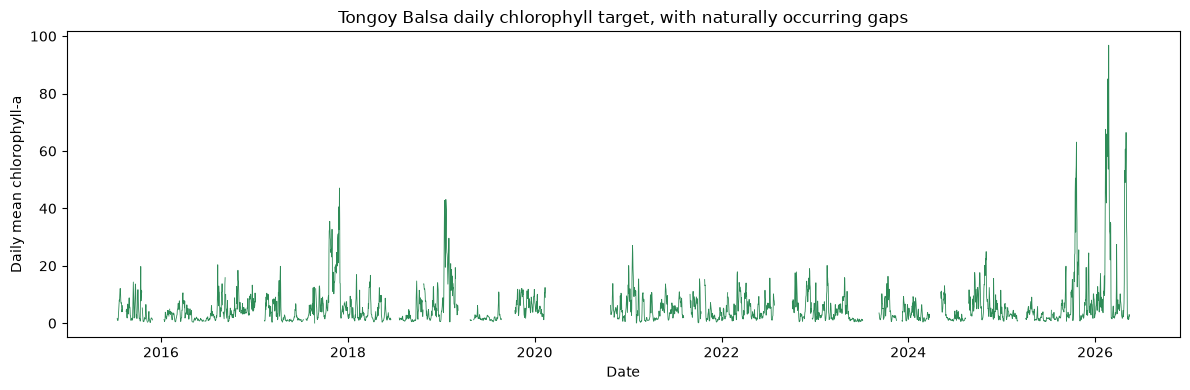

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(target_df.index, target_df["chl_mean"], lw=0.6, color="seagreen")
ax.set_xlabel("Date")
ax.set_ylabel("Daily mean chlorophyll-a")
ax.set_title("Tongoy Balsa daily chlorophyll target, with naturally occurring gaps")
plt.tight_layout()
plt.show()

## Artificial-gap validation pool

Real gaps (above) have no withheld ground truth: the sensor was genuinely
offline, so there's nothing to compare a reconstruction against. To get
quantitative evidence about reconstruction accuracy, this benchmark instead
picks stretches of the record that ARE observed, deliberately hides the
true values for a block of consecutive days, runs a candidate method as if
those days were missing, and scores its predictions against the secretly
retained true values.

**Leakage prevention, in brief**: only the target column is masked for an
artificial gap (external predictor data at the same dates stays visible,
mirroring a real deployment where the sensor fails but other sources keep
reporting); any feature computed from the target's own history becomes
missing if it would reach into the hidden gap; scoring uses only the
secretly retained true values of hidden days, never visible days. See
`docs/methods.md` for the full leakage-control description.

In [7]:
from coastal_gap_reconstruction.data_loading import load_validation_gap_pool

gap_pool = load_validation_gap_pool("../data/chlorophyll/chlorophyll_validation_gaps.csv")
print(f"Total artificial gaps in canonical pool: {len(gap_pool)}")
gap_pool.head()

Total artificial gaps in canonical pool: 681


,gap_id,gap_length,start_date,end_date,n_hidden_days,season,year,target_mean_true,target_max_true,chl_90th_threshold,is_high_chl_event,is_sustained_event,is_background,pre_context_available_days,post_context_available_days,context_constrained,regime,target_table_checksum
0,L01_20150715,1,2015-07-15,2015-07-15,1,JJA,2015,1.0391,1.0391,11.3253,False,False,True,0,19,True,strict_observed_only,f9553abf559d224262061ea9002ca9fe33b81317891ced...
1,L01_20150820,1,2015-08-20,2015-08-20,1,JJA,2015,2.5656,2.5656,11.3253,False,False,True,15,29,True,strict_observed_only,f9553abf559d224262061ea9002ca9fe33b81317891ced...
2,L01_20150908,1,2015-09-08,2015-09-08,1,SON,2015,1.6435,1.6435,11.3253,False,False,True,20,29,True,strict_observed_only,f9553abf559d224262061ea9002ca9fe33b81317891ced...
3,L01_20151027,1,2015-10-27,2015-10-27,1,SON,2015,0.7292,0.7292,11.3253,False,False,True,29,25,True,strict_observed_only,f9553abf559d224262061ea9002ca9fe33b81317891ced...
4,L01_20160206,1,2016-02-06,2016-02-06,1,DJF,2016,4.1310,4.1310,11.3253,False,False,True,19,30,True,strict_observed_only,f9553abf559d224262061ea9002ca9fe33b81317891ced...


## Gap-length distribution

In [8]:
length_counts = gap_pool["gap_length"].value_counts().sort_index()
length_counts

gap_length
1     100
3     100
7     100
10    100
14    100
21     80
30     50
45     29
60     22
Name: count, dtype: int64

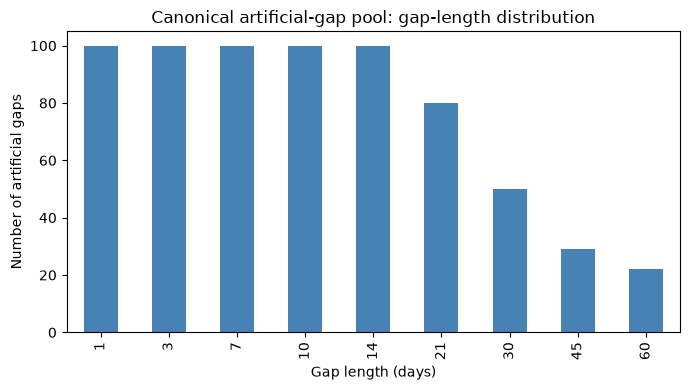

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
length_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_xlabel("Gap length (days)")
ax.set_ylabel("Number of artificial gaps")
ax.set_title("Canonical artificial-gap pool: gap-length distribution")
plt.tight_layout()
plt.show()

## Season and event-status breakdown

In [10]:
print(gap_pool["season"].value_counts())
print()
print(gap_pool["is_high_chl_event"].value_counts())

season
DJF    187
SON    186
MAM    170
JJA    138
Name: count, dtype: int64

is_high_chl_event
False    482
True     199
Name: count, dtype: int64


## Maximum validated gap length

The canonical pool covers gap lengths up to 60 days. Any reconstruction
claim for a longer gap (e.g. the 256-day real gap in this record) is
extrapolation beyond validated evidence -- see
`docs/evidence_and_limitations.md`.